In [3]:
import json
import os
import sys
import random

root_dir = os.path.abspath(os.path.join(os.path.dirname(os.getcwd()), '.'))
sys.path.append(root_dir)

from constants import *

import numpy as np

# import my_plot
from my_plot import *

from file_reader import *

import json


folder= "../../../../../应用/Overleaf/" + "Benchmarking RL Spatial Index"


In [4]:

# Open and read the JSON file
with open("best_models_grid_search.json", "r") as json_file:
    output_dict = json.load(json_file)

# Print the contents (optional)
# for dataset, indices in output_dict.items():
#     print(f"Dataset: {dataset}")
#     for index, model in indices.items():
#         print(f"  Index: {index}, Best Model: {model}")

### Parameters

In [5]:
# baselines = ['bmtree', 'kdtree', 'ketree_greddy', 'qdtree', 'r_star_tree', 'rankspace_zorder', 'rlrtree', 'rtree', 'zorder']
build_result_path = "../result/libspatialindex/HDD/4K/{name}/build/"
point_result_path = "../result/libspatialindex/HDD/4K/{name}/point/"
range_result_path = "../result/libspatialindex/HDD/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/HDD/4K/{name}/knn/"
insert_result_path = "../result/libspatialindex/HDD/4K/{name}/insert/"
insert_point_result_path = "../result/libspatialindex/HDD/4K/{name}/insert_point/"

baseline_suffix = {'bmtree':'_bits_32_depth_12_sample_10000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_400',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_80000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}


data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM",  "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
baselines = ['rtree', 'r_star_tree',  'kdtree', 'kdtree_greedy','zorder', 'rankspace_zorder']
baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'qdtree']
baselines = ['rtree', 'r_star_tree', 'platon', 'rlrtree', 'zorder', 'rankspace_zorder', 'zm', 'bmtree', 'kdtree', 'kdtree_greedy', 'lisa', 'qdtree']
display_baselines = ['RT', 'RST', 'KD', 'KDG','ZR', 'ZRR']
display_baselines = ['RT', 'RST', 'RLR', 'KD', 'KDG', 'QD','ZR', 'ZRR', 'BMT']
display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']
display_baselines = ['R-tree', 'R*-tree', 'PLATON', 'RLR-tree','ZR-tree', 'ZRR-tree', 'ZM', 'BM-tree', 'Kd-tree', 'GKd-tree', 'LISA', 'Qd-tree']

In [6]:
data_names = ["us_100000000"]
data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000"]
display_data_names = ["US"]
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

data_name = "us_100000000"
query_ranges=[0.0001, 0.0005, 0.001, 0.005, 0.01]

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_{r1}x{r2}"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_{r1}x{r2}"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

# baselines = ['rlrtree', 'qdtree',  'bmtree']
# display_baselines = ['RLR-tree', 'Qd-tree', 'BM-tree']


In [9]:
disk_types = ["HDD", "SSD"]

query_types = ["Index Building", "Point Query", "Range Query", "$k$NN Query"]

build_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/build/"
point_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/point/"
range_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/range/"
knn_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/knn/"
join_result_path = "../result/libspatialindex/{disk_type}/4K/{name}/join/"
# baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
#                    'kdtree':'',
#                    'kdtree_greedy':'',
#                    'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
#                    'r_star_tree':'_rstar',
#                    'rankspace_zorder':'_bits_32',
#                    'rlrtree':'_rlrtree_epoch_10_sample_10000',
#                    'rtree':'_quadratic',
#                    'zorder':'_bits_32'}

data_names = ["us_100000000"]
display_data_names = ["US"]
real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']
# baselines = ['rtree', 'r_star_tree', 'rlrtree', 'kdtree', 'kdtree_greedy', 'qdtree', 'zorder', 'rankspace_zorder', 'bmtree']
# display_baselines = ['R-tree', 'R*-tree', 'RLR-tree', 'Kd-tree', 'GKd-tree', 'Qd-tree','ZR-tree', 'ZRR-tree', 'BM-tree']

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']
knn_result_name_pattern = "{data_name}{default_range_name}_{knn_name}_k_{k}{suffix}.txt"
real_knn_name = "{data_name}_knn_1000_2_uniform_1"
synthetic_knn_name = "knn_1000_2_uniform_1"


synthetic_insert_point_name = "insert_point_10000000_{data_name}_2_uniform_1"
insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_2_18{suffix}.txt"
real_insert_point_name = "{data_name}_insert_point_10000000_2_uniform_1"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"


real_join_name_pattern = "{data_name}_join_1000_2_uniform_1_0.001x0.001"
synthetic_join_name_pattern = "join_1000_2_uniform_1_0.001x0.001"
join_result_name_pattern = "{data_name}{default_range_name}_{join_name}{suffix}.txt"



In [14]:
data_name = "us_100000000"
k=25
point_query = []
range_query = []
knn_query = []
build_time = []
spatial_join = []

for baseline in baselines:
    point_query_sampled = []
    range_query_sampled = []
    knn_query_sampled = []
    build_time_sampled = []
    spatial_join_sampled = []
    for disk_type in disk_types:    

        suffix = baseline_suffix[baseline]


        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            knn_name = synthetic_knn_name
            join_name = synthetic_join_name_pattern
            
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            join_name = real_join_name_pattern.format(data_name=data_name)

        # default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
        range_name=real_range_name_pattern.format(data_name=data_name)
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        # print(build_result_name)
        res = os.path.join(build_result_path.format(name=baseline,disk_type=disk_type), build_result_name)
        tree_property = parse_rtree_properties(res)
        # build_time_sampled.append(tree_property.ElapsedLearnTime / 1e9)
        build_time_sampled.append(tree_property.ElapsedTime / 1e9)
        
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix
        )

        
        res = os.path.join(point_result_path.format(name=baseline,disk_type=disk_type), point_result_name)
        tree_property = parse_rtree_properties(res)
        # print(res)
        point_query_sampled.append(tree_property.QueryMean / 1e3)


        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        # print(range_result_name)

        res = os.path.join(range_result_path.format(name=baseline,disk_type=disk_type), range_result_name)
        tree_property = parse_rtree_properties(res)
        range_query_sampled.append(tree_property.QueryMean / 1e3)

        # join_result_name = join_result_name_pattern.format(
        #     data_name=data_name,
        #     default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
        #     join_name=join_name,
        #     suffix=suffix
        # )
        # # print(range_result_name)

        # res = os.path.join(join_result_path.format(name=baseline,disk_type=disk_type), join_result_name)
        # print(res)
        # tree_property = parse_rtree_properties(res)
        # spatial_join_sampled.append(tree_property.QueryMean / 1e3)

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline,disk_type=disk_type), knn_result_name)
        tree_property = parse_rtree_properties(res)
        knn_query_sampled.append(tree_property.QueryMean / 1e3)

        # print(build_result_path.format(name=baseline,disk_type=disk_type), build_result_name)
        # print(point_result_path.format(name=baseline,disk_type=disk_type),point_result_name)
        # print(range_result_path.format(name=baseline,disk_type=disk_type), range_result_name)
        # print(knn_result_path.format(name=baseline,disk_type=disk_type), knn_result_name)
    #     break
    # break

    point_query.append(point_query_sampled)
    range_query.append(range_query_sampled)
    knn_query.append(knn_query_sampled)
    build_time.append(build_time_sampled)
    # spatial_join.append(spatial_join_sampled)
    


print(point_query)
# print(range_query)
# print(knn_query)
# print(build_time)
print(spatial_join)

[[253.07302223500002, 209.514627965], [70.461524125, 58.131101900000004], [33.53576615, 26.560773155], [257.39721486999997, 232.78219282], [133.541728845, 110.22995365999999], [100.08021472, 89.01221596], [277.47719153, 269.028526425], [133.95570627, 116.281231105], [51.254086335, 37.357784795], [2110.243643405, 42.52414486999999], [260.05939003000003, 0.0], [47.481811994999994, 38.72696189]]
[]


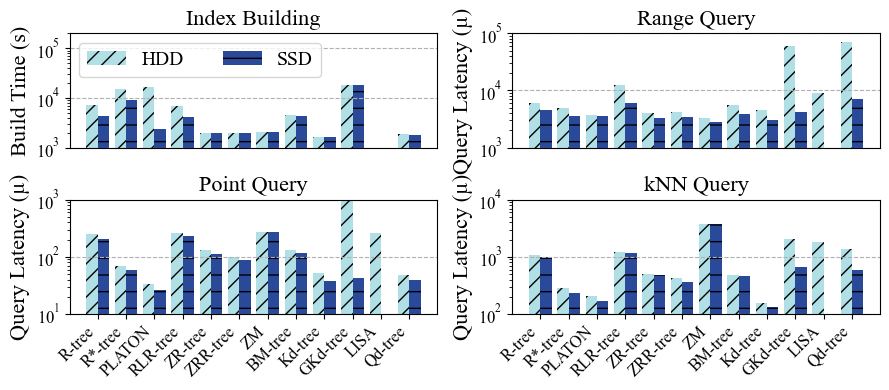

In [7]:
# import matplotlib.pyplot as plt
# import numpy as np
# colors = ['#A9A9F5', '#FFD700', '#88CCEE', '#FFCC99', '#FFA07A', '#FF6F61', '#B0E0E6', '#2CA02C', '#AA4499']

all_data = [build_time, range_query, point_query, knn_query]
query_types = ['Index Building', 'Range Query', 'Point Query', 'kNN Query']
bottoms = [1e3, 1*1e3, 1e1, 1e2]
tops = [2*1e5, 1*1e5, 1*1e3, 1*1e4]

# display_baselines = [f'Baseline {i+1}' for i in range(9)]  #

group_width = 0.8  
individual_bar_width = group_width / 2  
offset = individual_bar_width / 2  

fig, axes = plt.subplots(2, 2, figsize=(9, 4), sharey=False)

for i, (ax, query_type, data) in enumerate(zip(axes.flat, query_types, all_data)):
    x = np.arange(len(display_baselines)) 
    
    hdd_values = [row[0] for row in data] 
    ssd_values = [row[1] for row in data] 
    
    ax.bar(x - offset, hdd_values, individual_bar_width, label='HDD', color=colors[0], alpha=1.0, hatch='//') 
    ax.bar(x + offset, ssd_values, individual_bar_width, label='SSD', color=colors[3], alpha=1.0, hatch='-') 

    ax.set_title(f'{query_type}', fontsize=16)
    
    if i > 1:
        ax.set_xticks(x)  
        ax.set_xticklabels(display_baselines, rotation=45, ha='right', fontsize=12) 
    else:
        ax.set_xticks([])  

    if i == 0:
        ax.set_ylabel('Build Time (s)', fontsize=16) 
    else:
        ax.set_ylabel('Query Latency (µ)', fontsize=16) 

    ax.set_ylim(bottom=bottoms[i])
    ax.set_ylim(top=tops[i])

    ax.tick_params(axis='y', labelsize=12)

    ax.set_yscale('log')
    ax.grid(True, axis='y', linestyle='--', alpha=1.0)

axes[0, 0].legend(loc='upper left', fontsize=14, ncol=2)  

output_file_paths = [folder + "/exp_sigmod/hdd_vs_ssd.pdf", "../figs/exp_sigmod/hdd_vs_ssd.png"]

plt.tight_layout()

if output_file_paths:
    for output_file_path in output_file_paths:
        if output_file_path.endswith(".pdf"):
            plt.savefig(output_file_path, format='pdf', bbox_inches='tight')
        if output_file_path.endswith(".png"):
            plt.savefig(output_file_path, format='png', bbox_inches='tight')


plt.show()

In [8]:

data_names = ["us_100000000", "india_100000000", "australia_100000000", "data_100000000_2_uniform_1", "data_100000000_2_normal_1", "data_100000000_2_skewed_4"]
data_names_write = ["us_10000000", "india_10000000", "australia_10000000", "data_10000000_2_uniform_1", "data_10000000_2_normal_1", "data_10000000_2_skewed_4"]
display_data_names = ["US", "INDIA", "AUS", "UNI", "NORM", "SKEW"]

real_default_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_default_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
build_result_name_pattern = "{data_name}{default_range_name}{suffix}.txt"

real_range_name_pattern = "_{data_name}_range_1000_2_uniform_1_0.001x0.001"
synthetic_range_name_pattern = "_range_1000_2_uniform_1_0.001x0.001"
range_result_name_pattern = "{data_name}{range_name}{suffix}.txt"

real_point_name = "{data_name}_point_200000_2_uniform_1"
synthetic_point_name = "point_200000_{data_name}_2_uniform_1"
point_result_name_pattern = "{data_name}{default_range_name}_{point_name}{suffix}.txt"
# special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree']

insert_point_result_name_pattern = "{data_name}{default_range_name}_{insert_point_name}_10_10{suffix}.txt"
synthetic_insert_name = "insert_10000000_2_uniform_1"
real_insert_name = "{data_name}_insert_10000000_2_uniform_1"
insert_result_name_pattern = "{data_name}{default_range_name}_{insert_name}{suffix}.txt"

spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize

    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_write_only[display_baseline] = tree_property.InsertMean

        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean    

    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)

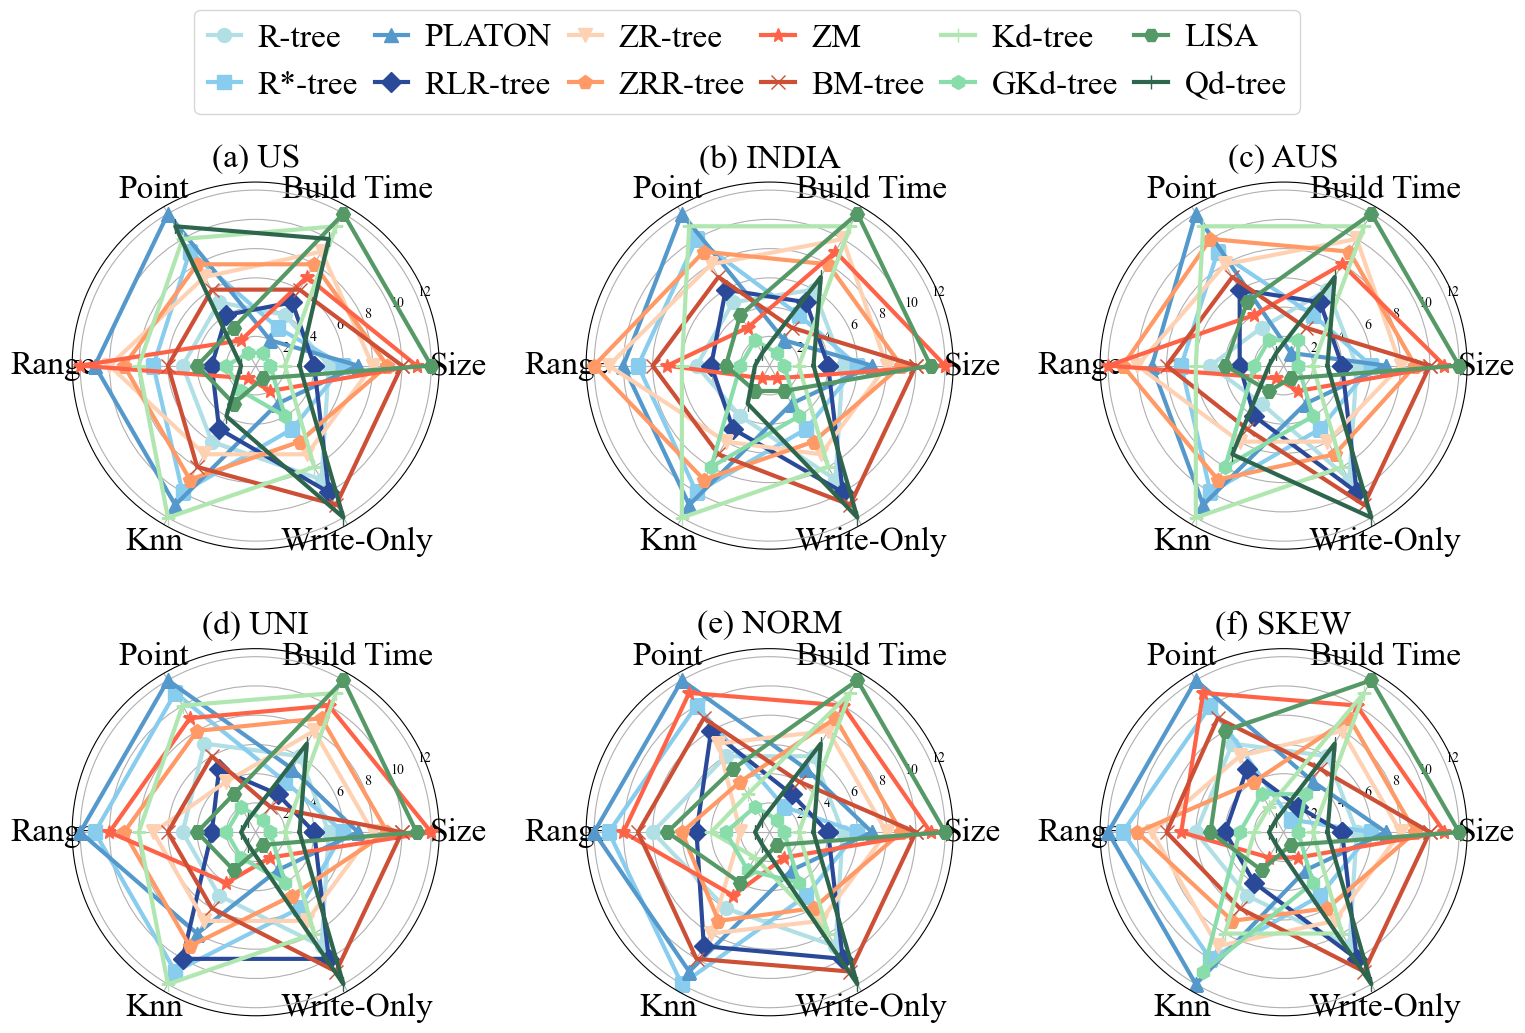

In [9]:
# import matplotlib.pyplot as plt
# import numpy as np


label_size = 24
legend_size = 20
categories = ['Size', 'Build Time', 'Point', 'Range', 'Knn', 'Write-Only']
letters = ["(a)", "(b)", "(c)", "(d)", "(e)", "(f)"]
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Define the number of subplots (2 rows, 3 columns for 6 subplots)
fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(18, 12), subplot_kw=dict(polar=True))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

# markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+', '|', '>', '<']
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+', 'h', 'H', '|']

linestyles = [None, None, None,'-', None, None, None,'--', None, None, None,'-.']

for j, ax in enumerate(axs):

    # baseline = []
    for i, display_baseline in enumerate(display_baselines):

        baseline = [
        spider_index_size[j][display_baseline],
        spider_build_time[j][display_baseline],
        spider_point_query[j][display_baseline],
        spider_range_query[j][display_baseline],
        spider_knn_query[j][display_baseline],
        # spider_balanced[j][display_baseline],
        spider_write_only[j][display_baseline]]
        # baseline = [random.randint(1, 9) for _ in range(len(categories))]
        baseline += baseline[:1]
        ax.plot(angles, baseline, color=colors[i], linewidth=3, marker=markers[i], markersize=10, label=display_baseline)


    # Fill in the labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=label_size)
    ax.set_title(letters[j] + " " + display_data_names[j], fontsize=label_size)

#     if j == 1:
#         # Add a legend for each subplot
#         ax.legend(loc='upper center', fontsize=legend_size, bbox_to_anchor=(0.5, 1.15), ncol=9)  # Adjust the position and columns

fig.legend(display_baselines, loc='upper center', fontsize=label_size, ncol=6, 
           handlelength=1,           
                handletextpad=0.5,   
                columnspacing=0.5,
           bbox_to_anchor=(0.5, 1.0))

        # borderaxespad=0.5,  # Border padding
        # handletextpad=0.5,  # Padding between legend marker and text
        # labelspacing=0.3    # Vertical space between legend entries

# Adjust layout to prevent overlap
# plt.tight_layout(rect=[0, 0, 1, 0.95])  # Adjust layout to make room for the legend

# plt.tight_layout(pad=1.0, w_pad=2.0, h_pad=0.0)

# pad: Padding between the figure edge and the edges of subplots.
# w_pad: Padding (width) between subplots.
# h_pad: Padding (height) between subplots.

# left, right, top, bottom: Control the margins around the entire figure.
# wspace: Controls the width space between the subplots.
# hspace: Controls the height space between the subplots.

plt.subplots_adjust(wspace=0.4, hspace=0.02)


# Adjust layout to prevent overlap
# plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/spider.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/spider.png", format='png', bbox_inches='tight')

# Show the entire figure with all subplots
plt.show()


rtree 24479.6022277
r_star_tree 54895.0226892
platon 131053.3775301
rlrtree 63948.9366581
zorder 54287.6345639
rankspace_zorder 54761.3753775
zm 1.7976931348623157e+308
../result/libspatialindex/HDD/4K/bmtree/insert/us_10000000_us_10000000_range_1000_2_uniform_1_0.001x0.001_us_10000000_insert_10000000_2_uniform_1_bits_32_depth_10_sample_80000.txt
bmtree 131821.2852059
kdtree 35808.3682949
kdtree_greedy 71733.9168696
lisa 1381665.5276716
qdtree 62649.4267658
{'R-tree': 24479.6022277, 'R*-tree': 54895.0226892, 'PLATON': 131053.3775301, 'RLR-tree': 63948.9366581, 'ZR-tree': 54287.6345639, 'ZRR-tree': 54761.3753775, 'ZM': 1.7976931348623157e+308, 'BM-tree': 131821.2852059, 'Kd-tree': 35808.3682949, 'GKd-tree': 71733.9168696, 'LISA': 1381665.5276716, 'Qd-tree': 62649.4267658}
rtree 24749.5038001
r_star_tree 54338.343936
platon 133418.4432037
rlrtree 63591.8809003
zorder 54037.3017341
rankspace_zorder 53840.8119267
zm 1.7976931348623157e+308
../result/libspatialindex/HDD/4K/bmtree/insert/aus

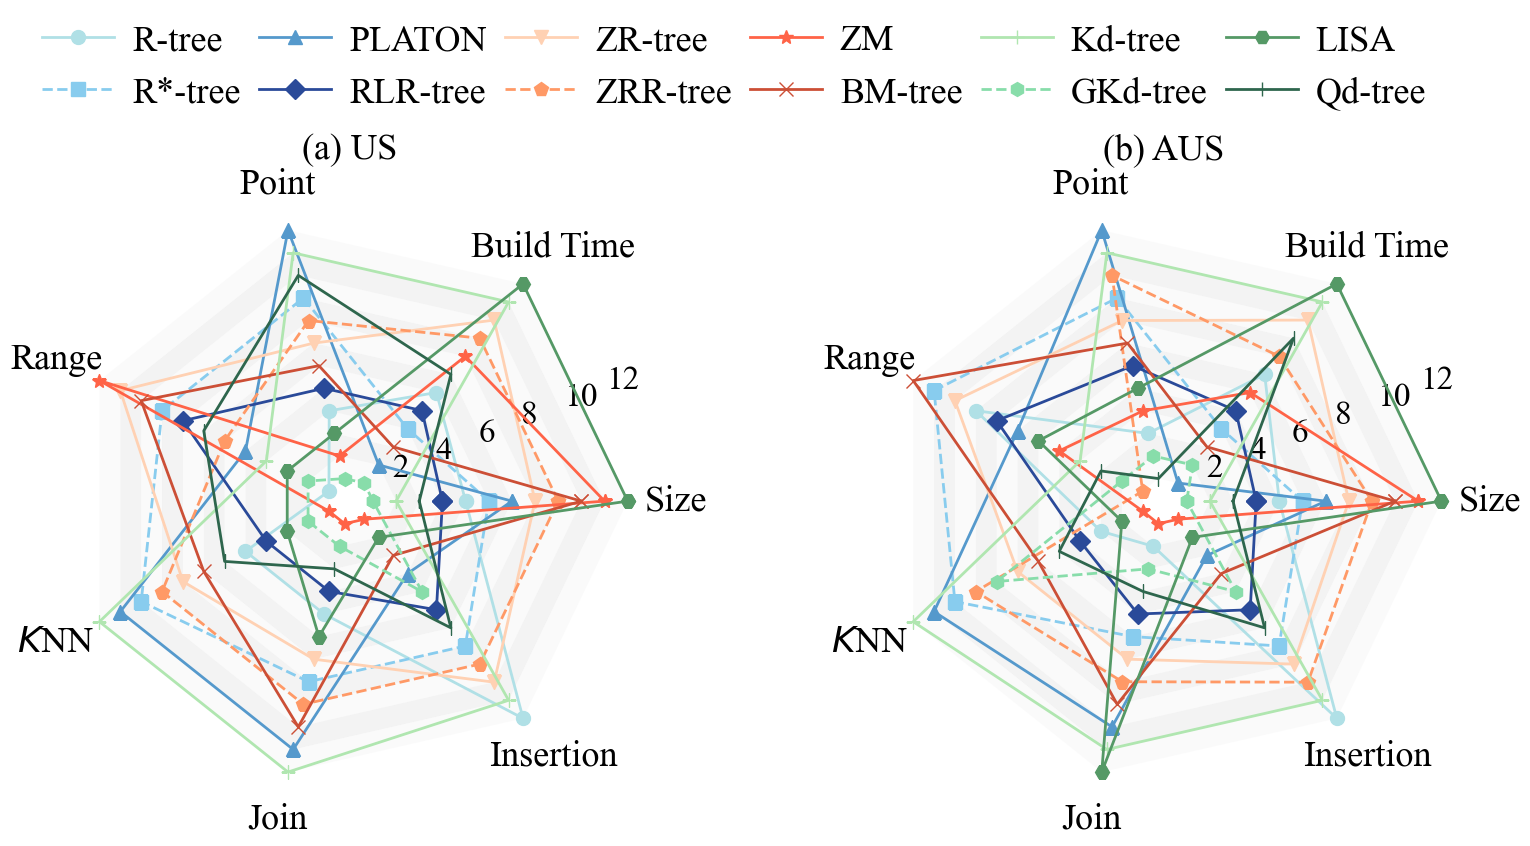

In [27]:
data_names = ["us_100000000", "australia_100000000"]
data_names_write = ["us_10000000", "australia_10000000"]
display_data_names = ["US", "AUS"]
markers = ['o', 's', '^', 'D', 'v', 'p', '*', 'x', '+', 'h', 'H', '|']


spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []
spider_spatial_join = []


baseline_suffix_map = {
                    "us_100000000": {'bmtree':'_bits_32_depth_10_sample_80000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0002_action_space_800',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_6_sample_80000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'},
                   "australia_100000000": {'bmtree':'_bits_32_depth_8_sample_40000', 
                   'kdtree':'',
                   'platon':'',
                   'zm':'_bits_32',
                   'waffle':'',
                   'kdtree_greedy':'',
                   'qdtree':'_episode_10_sampling_ratio_0.0008_action_space_200',
                   'r_star_tree':'_rstar',
                   'rankspace_zorder':'_bits_32',
                   'rlrtree':'_rlrtree_epoch_8_sample_10000',
                   'rtree':'_quadratic',
                   'lisa':'',
                   'zorder':'_bits_32'}
                  }

# baseline_suffix = {'bmtree':'_bits_32_depth_10_sample_10000', 
#                    'kdtree':'',
#                    'platon':'',
#                    'zmindex':'',
#                    'zm':'_bits_32',
#                    # 'waffle':'',
#                    'kdtree_greedy':'',
#                    'qdtree':'_episode_10_sampling_ratio_0.0001_action_space_200',
#                    'r_star_tree':'_rstar',
#                    'rankspace_zorder':'_bits_32',
#                    'rlrtree':'_rlrtree_epoch_10_sample_10000',
#                    'rtree':'_quadratic',
#                    'zorder':'_bits_32'}

special_baselines = ['bmtree', 'kdtree_greedy', 'rlrtree', 'qdtree', 'platon']

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}
    dict_spider_spatial_join = {}

    baseline_suffix = baseline_suffix_map[data_name]

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize
        
    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name
            join_name = synthetic_join_name_pattern

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            join_name = real_join_name_pattern.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        # if baseline in special_baselines:
        #     insert_name = synthetic_insert_name
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        
        spatial_join_result_name = join_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            join_name=join_name,
            suffix=suffix
        )
        res = os.path.join(join_result_path.format(name=baseline, disk_type="HDD"), spatial_join_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_spatial_join[display_baseline] = tree_property.QueryMean if baseline != 'zm' else sys.float_info.max

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)

        if baseline == 'bmtree':
            print(res)

        
        tree_property = parse_rtree_properties(res)
 
        dict_spider_write_only[display_baseline] = tree_property.InsertMean if baseline != 'zm' else sys.float_info.max
        print(baseline, dict_spider_write_only[display_baseline])
        
        # dict_spider_write_only[display_baseline] = tree_property.InsertMean
        
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean if baseline != 'zm' else sys.float_info.max

    print(dict_spider_write_only)
    
    
    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_spatial_join = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_spatial_join.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)
    spider_spatial_join.append(ranked_spider_spatial_join)

print("--------------------")
print(dict_spider_spatial_join)
print(spider_spatial_join)
print("--------------------")


import matplotlib.pyplot as plt
import numpy as np
import random

label_size = 24
legend_size = 20
categories = ['Size', 'Build Time', 'Point', 'Range', '$K$NN', 'Insertion']
categories = ['Size', 'Build Time', 'Point', 'Range', '$K$NN', "Join", 'Insertion']
letters = ["(a)", "(b)"]
num_vars = len(categories)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]

# Define the number of subplots (2 rows, 3 columns for 6 subplots)
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(18, 12), subplot_kw=dict(polar=True))

# Flatten the array of axes for easier iteration
axs = axs.flatten()

linestyles = ['-', '--', None, None]
background_colors = ['#f0f0f0', '#d9d9d9']
for j, ax in enumerate(axs):

    # for i in range(1, 12):  # Number of radial grid levels
    #     ax.fill_between(
    #         angles,
    #         i - 1, i,  # Radial range
    #         color=background_colors[i % 2],  # Alternate colors
    #         alpha=0.3  # Transparency
    #     )

    # baseline = []
    for i, display_baseline in enumerate(display_baselines):

        baseline = [
        spider_index_size[j][display_baseline],
        spider_build_time[j][display_baseline],
        spider_point_query[j][display_baseline],
        spider_range_query[j][display_baseline],
        spider_knn_query[j][display_baseline],
        spider_spatial_join[j][display_baseline],
        # spider_balanced[j][display_baseline],
        spider_write_only[j][display_baseline]]
        # baseline = [random.randint(1, 9) for _ in range(len(categories))]
        baseline += baseline[:1]
        linestyle = linestyles[i % len(linestyles)]
        ax.plot(angles, baseline, color=colors[i], linestyle=linestyle, linewidth=2, marker=markers[i], markersize=10, label=display_baseline)

    # Fill in the labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=label_size + 2)
    ax.tick_params(axis='x', pad=15)  
    ax.set_title(letters[j] + " " + display_data_names[j], fontsize=label_size + 2)

    ax.yaxis.grid(False)
    # Remove outer circle
    ax.spines['polar'].set_visible(False)

#     if j == 1:
#         # Add a legend for each subplot
#         ax.legend(loc='upper center', fontsize=legend_size, bbox_to_anchor=(0.5, 1.15), ncol=9)  # Adjust the position and columns

fig.legend(display_baselines, loc='upper center', fontsize=label_size + 2, ncol=6, 
           handlelength=2,           
                handletextpad=0.5,   
                columnspacing=0.5,
           frameon=False,     
           bbox_to_anchor=(0.5, 0.92))

for j, ax in enumerate(axs):

    for i in range(2, 13):  # Number of radial grid levels
        ax.fill_between(
            angles,
            i - 1, i,  # Radial range
            color=background_colors[i % 2],  # Alternate colors
            alpha=0.3,  # Transparency
            edgecolor='none'
        )
    ax.tick_params(axis='y', labelsize=label_size) 
    ax.spines['polar'].set_visible(False)  # Remove the outer circle
    ax.grid(False)  # Remove the gridlines
    ax.yaxis.grid(False)  # Disable radial gridlines
    ax.xaxis.grid(False)  # Disable angular gridlines
    
    # Optional: Adjust the appearance of the chart
    ax.set_frame_on(False)  # Ensure no frame is drawn around the plot

plt.subplots_adjust(wspace=0.4, hspace=0.02)


# Adjust layout to prevent overlap
# plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/spider_join.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/spider_join.png", format='png', bbox_inches='tight')

# Show the entire figure with all subplots
plt.show()


In [11]:
data_names = ["us_100000000", "australia_100000000"]
data_names_write = ["us_10000000", "australia_10000000"]
display_data_names = ["US", "AUS"]

data_names = ["us_100000000"]
data_names_write = ["us_10000000"]
display_data_names = ["US"]


spider_build_time = []
spider_index_size = []
spider_point_query = []
spider_range_query = []
spider_knn_query = []
spider_balanced = []
spider_write_only = []

for data_name, data_name_write in zip(data_names, data_names_write):

    dict_spider_build_time = {}
    dict_spider_index_size = {}
    dict_spider_point_query = {}
    dict_spider_range_query = {}
    dict_spider_knn_query = {}
    dict_spider_balanced = {}
    dict_spider_write_only = {}


    baseline_suffix = baseline_suffix_map[data_name]

    for baseline, display_baseline in zip(baselines, display_baselines):
        suffix = baseline_suffix[baseline]
        
    
    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]

        print(suffix)
        
        default_range_name = ''
        default_range_name_write = ''
        if baseline in special_baselines:
            if data_name.startswith("data"):
                default_range_name = synthetic_default_range_name_pattern
                default_range_name_write = default_range_name
            else:
                default_range_name = real_default_range_name_pattern.format(data_name=data_name)
                default_range_name_write = real_default_range_name_pattern.format(data_name=data_name_write)
        
        build_result_name = build_result_name_pattern.format(
            data_name=data_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(build_result_path.format(name=baseline, disk_type="HDD"), build_result_name)

        tree_property = parse_rtree_properties(res)

        dict_spider_build_time[display_baseline] = tree_property.ElapsedTime
        dict_spider_index_size[display_baseline] = tree_property.TreeDatSize + tree_property.TreeIdxSize

    # for baseline, display_baseline in zip(baselines, display_baselines):
    #     suffix = baseline_suffix[baseline]
        if data_name.startswith("data"):
            default_range_name = synthetic_default_range_name_pattern if baseline in special_baselines else ''
            point_name = synthetic_point_name.format(data_name=data_name)
            range_name = synthetic_range_name_pattern
            knn_name = synthetic_knn_name

            insert_name = synthetic_insert_name
            insert_point_name = synthetic_insert_point_name.format(data_name=data_name_write) 
        else:
            default_range_name=real_default_range_name_pattern.format(data_name=data_name) if baseline in special_baselines else ''
            point_name = real_point_name.format(data_name=data_name)
            range_name=real_range_name_pattern.format(data_name=data_name)
            knn_name = real_knn_name.format(data_name=data_name)
            
            insert_name=real_insert_name.format(data_name=data_name_write) 
            insert_point_name=real_insert_point_name.format(data_name=data_name_write) 
            
        point_result_name = point_result_name_pattern.format(
            data_name=data_name,
            point_name=point_name,
            default_range_name=default_range_name,
            suffix=suffix
        )
        res = os.path.join(point_result_path.format(name=baseline, disk_type="HDD"), point_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_point_query[display_baseline] = tree_property.QueryMean

        range_result_name = range_result_name_pattern.format(
            data_name=data_name,
            range_name=range_name,
            suffix=suffix
        )
        res = os.path.join(range_result_path.format(name=baseline, disk_type="HDD"), range_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_range_query[display_baseline] = tree_property.QueryMean

        knn_result_name = knn_result_name_pattern.format(
            data_name=data_name,
            knn_name=knn_name,
            default_range_name=default_range_name.format(data_name=data_name) if baseline in special_baselines else '',
            suffix=suffix,
            k=k
        )
        res = os.path.join(knn_result_path.format(name=baseline, disk_type="HDD"), knn_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_knn_query[display_baseline] = tree_property.QueryMean

        insert_result_name = insert_result_name_pattern.format(
            data_name=data_name_write,
            insert_name=insert_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_result_path.format(name=baseline), insert_result_name)
        tree_property = parse_rtree_properties(res)
        dict_spider_write_only[display_baseline] = tree_property.InsertMean
        
        insert_point_result_name = insert_point_result_name_pattern.format(
            data_name=data_name_write,
            insert_point_name=insert_point_name,
            default_range_name=default_range_name_write,
            suffix=suffix
        )
        res = os.path.join(insert_point_result_path.format(name=baseline), insert_point_result_name)
        tree_property = parse_rtree_properties(res)
        # dict_spider_balanced[display_baseline] = tree_property.QueryMean
        dict_spider_balanced[display_baseline] = tree_property.InsertMean    


    print(dict_spider_write_only)
    ranked_spider_build_time = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_build_time.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_index_size = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_index_size.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_point_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_point_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_range_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_range_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_knn_query = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_knn_query.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_balanced = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_balanced.items(), key=lambda item: item[1], reverse=True), 1)
    }

    ranked_spider_write_only = {
        baseline: rank for rank, (baseline, _) in enumerate(sorted(dict_spider_write_only.items(), key=lambda item: item[1], reverse=True), 1)
    }

    spider_build_time.append(ranked_spider_build_time)
    spider_index_size.append(ranked_spider_index_size)
    spider_point_query.append(ranked_spider_point_query)
    spider_range_query.append(ranked_spider_range_query)
    spider_knn_query.append(ranked_spider_knn_query)
    spider_balanced.append(ranked_spider_balanced)
    spider_write_only.append(ranked_spider_write_only)

def rank_to_stars(rank):
    if 1 <= rank <= 4:
        return '★'
    elif 5 <= rank <= 8:
        return '★★'
    elif 9 <= rank <= 11:
        return '★★★'

# 填充表格
table_rows = []
# for index in indices:
for i, index in enumerate(display_baselines):
    build = rank_to_stars(spider_build_time[0][index])
    size = rank_to_stars(spider_index_size[0][index])
    point = rank_to_stars(spider_point_query[0][index])
    range_ = rank_to_stars(spider_range_query[0][index])
    knn = rank_to_stars(spider_knn_query[0][index])
    insertion = rank_to_stars(spider_write_only[0][index])
    table_rows.append(f"{index} & {size} & {build} & {point} & {range_} & {knn} & {insertion} \\\\ \\hline")

# 打印完整的表格代码
print("\\begin{table}[h!]\n\\small\n\\centering")
print("\\caption{Performance evaluation for various spatial indices.}")
print("\\begin{tabular}{c|c|c|c|c|c|c}")
print("\\toprule")
print("Index & Size & Build & Point & Range & $K$NN & Insertion \\\\ ")
print("\\midrule")
print("\\midrule")
for row in table_rows:
    print(row)
print("\\bottomrule")
print("\\end{tabular}")
print("\\label{tab:performance_evaluation}")
print("\\end{table}")

_quadratic
_rstar

_rlrtree_epoch_6_sample_80000
_bits_32
_bits_32
_bits_32
_bits_32_depth_10_sample_80000



_episode_10_sampling_ratio_0.0002_action_space_800
{'R-tree': 24479.6022277, 'R*-tree': 54895.0226892, 'PLATON': 131053.3775301, 'RLR-tree': 63948.9366581, 'ZR-tree': 54287.6345639, 'ZRR-tree': 54761.3753775, 'ZM': 445531.0, 'BM-tree': 131821.2852059, 'Kd-tree': 35808.3682949, 'GKd-tree': 71733.9168696, 'LISA': 1381665.5276716, 'Qd-tree': 62649.4267658}
\begin{table}[h!]
\small
\centering
\caption{Performance evaluation for various spatial indices.}
\begin{tabular}{c|c|c|c|c|c|c}
\toprule
Index & Size & Build & Point & Range & $K$NN & Insertion \\ 
\midrule
\midrule
R-tree & ★★ & ★★ & ★ & ★★ & ★★ & None \\ \hline
R*-tree & ★★ & ★ & ★★★ & ★★ & ★★★ & ★★ \\ \hline
PLATON & ★★ & ★ & None & ★★★ & ★★★ & ★ \\ \hline
RLR-tree & ★ & ★★ & ★★ & ★ & ★ & ★★ \\ \hline
ZR-tree & ★★ & ★★★ & ★★ & ★★★ & ★★ & ★★★ \\ \hline
ZRR-tree & ★★★ & ★★★ & ★★ & ★★ & ★★★ & ★★★ \\ \hline
ZM & ★★★ & ★★ & ★ & N

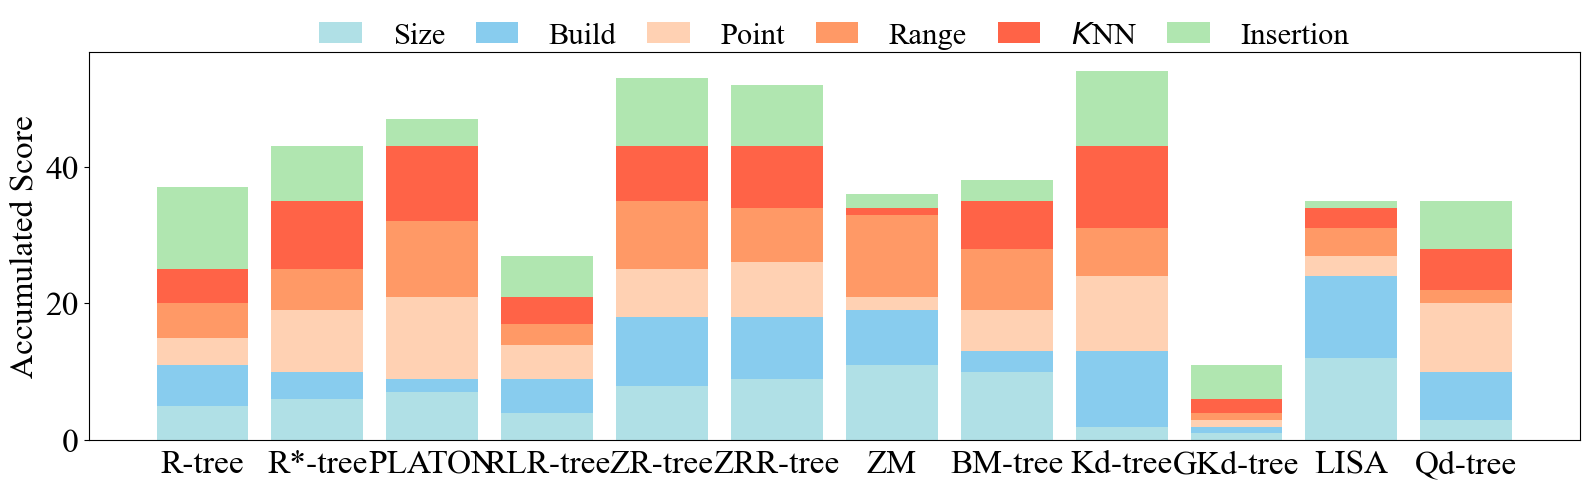

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# metrics = ['Size', 'Build', 'Point', 'Range', '$K$NN', 'Insertion']
metrics = ['Size', 'Build', 'Point', 'Range', '$K$NN', 'Insertion']

rank_list = [spider_index_size[0], spider_build_time[0], spider_point_query[0], spider_range_query[0],
             spider_knn_query[0], spider_write_only[0]]
# Ranks for each index and metric (example values)

ranks = {}
for i, index in enumerate(display_baselines):
    index_rank = []
    for metric_rank in rank_list:
        index_rank.append(metric_rank[index])
    ranks[index] = index_rank
    

# Prepare data for the stacked histogram
data = np.array([ranks[index] for index in display_baselines]).T
bar_width = 0.8

# Colors for the metrics
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#C299FF', '#FF6666']
colors = ['#B0E0E6', '#88CCEE', 
          '#FFD1B3', '#FF9966', '#FF6347',
          '#B0E6B0', '#88DDAA', '#559966']
# Plotting the stacked histogram
fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(display_baselines))

x_shift = x - bar_width / 2  # Center the bars on the tick marks
# Stack the bars
bottom = np.zeros(len(display_baselines))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x, data[i], bar_width, label=metric, color=color, bottom=bottom)
    bottom += data[i]

# Customize the plot
ax.set_xticks(x)  # Ensure ticks are at the center of each bar group
# ax.set_xticklabels(display_baselines, rotation=45, fontsize=label_size)
ax.set_xticklabels(display_baselines, fontsize=label_size-3)


ax.tick_params(axis='x', which='both', bottom=False, labelsize=label_size)
ax.tick_params(axis='y', which='both', labelsize=label_size)
ax.set_ylabel('Accumulated Score', fontsize=label_size)

# Customize legend
legend = plt.legend(
    loc='upper center',          
    bbox_to_anchor=(0.5, 1.15),  
    ncol=6,                      
    frameon=False,     
    fontsize=legend_size + 2,
    handlelength=1.4,
    handletextpad=1,
    columnspacing=1,
    labelspacing=0.1
)
plt.setp(legend.get_title(), fontsize=legend_size)

# Display the plot
plt.tight_layout()

plt.savefig(folder + "/exp_sigmod/overall_stack.pdf", format='pdf', bbox_inches='tight')
plt.savefig("../figs/exp_sigmod/overall_spider.png", format='png', bbox_inches='tight')

plt.show()
